In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import cv2
import os

In [74]:
os.listdir('/kaggle/input/glasses-classification-dataset')

['validate', 'test', 'train']

In [75]:
data_train = {
    'glasses':0,
    'noglasses':1
}

In [76]:
X_train = []
y_train = []
for i in os.listdir('/kaggle/input/glasses-classification-dataset/train'):
    try:
        for j in os.listdir(f'/kaggle/input/glasses-classification-dataset/train/{i}'):
            image = img.imread(f'/kaggle/input/glasses-classification-dataset/train/{i}/{j}')
            image = cv2.resize(image, (155,155))
            if len(image.shape) == 3:
                image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
            image = image.reshape(155,155,1)
            image = image / 255
            X_train.append(image)
            y_train.append(data_train[i])            
    except:
        print(j)
X_train = np.array(X_train)    
y_train = np.array(y_train)    

In [77]:
X_train.shape

(104, 155, 155, 1)

In [78]:
y_train.shape

(104,)

In [82]:
X_val = []
y_val = []
for i in os.listdir('/kaggle/input/glasses-classification-dataset/validate'):
    try:
        for j in os.listdir(f'/kaggle/input/glasses-classification-dataset/validate/{i}'):
            image = img.imread(f'/kaggle/input/glasses-classification-dataset/validate/{i}/{j}')
            image = cv2.resize(image, (155,155))
            if len(image.shape) == 3:
                image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
            image = image.reshape(155,155,1)
            image = image / 255
            X_val.append(image)
            y_val.append(data_train[i])            
    except:
        print(j)
X_val = np.array(X_val)    
y_val = np.array(y_val)   

In [83]:
X_val.shape

(40, 155, 155, 1)

In [84]:
y_val.shape

(40,)

In [85]:
data_test = {
    '1': 0,
    '7':1
}

In [86]:
X_test = []
y_test = []
for i in os.listdir('/kaggle/input/glasses-classification-dataset/test'):
    try:
        image = img.imread(f'/kaggle/input/glasses-classification-dataset/test/{i}')
        image = cv2.resize(image, (155,155))
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        image = image.reshape(155,155,1)
        image = image / 255 
        X_test.append(image)
        y_test.append(data_test[i.split('-')[1]]) 
    except:
        print(i)
X_test = np.array(X_test)    
y_test = np.array(y_test) 

In [87]:
X_test.shape

(20, 155, 155, 1)

In [88]:
y_test.shape

(20,)

In [89]:
from sklearn.utils import shuffle

In [90]:
X_train,y_train = shuffle(X_train,y_train, random_state=42)
X_test,y_test = shuffle(X_test,y_test, random_state=42)
X_val,y_val = shuffle(X_val,y_val, random_state=42)

In [101]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from keras.optimizers import Adam

In [172]:
model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=(155,155,1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(units=258, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

In [173]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [174]:
model.fit(X_train,y_train, validation_data=(X_val,y_val), epochs=10, batch_size=32)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5508 - loss: 6.1597 - val_accuracy: 0.5000 - val_loss: 4.9624
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4719 - loss: 4.1244 - val_accuracy: 0.5000 - val_loss: 3.6134
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5139 - loss: 3.2691 - val_accuracy: 0.7250 - val_loss: 0.6270
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5623 - loss: 1.1791 - val_accuracy: 0.5000 - val_loss: 1.5069
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5272 - loss: 1.2992 - val_accuracy: 0.5000 - val_loss: 0.9385
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5240 - loss: 1.0386 - val_accuracy: 0.5000 - val_loss: 0.7004
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6171 - loss: 0.8256 - val_accuracy: 0.6250 - val_loss: 0.6205
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6187 - loss: 0.6617 - val_accuracy: 0.6750 - val_loss: 0.6121
Epoch 9/10
4/4 

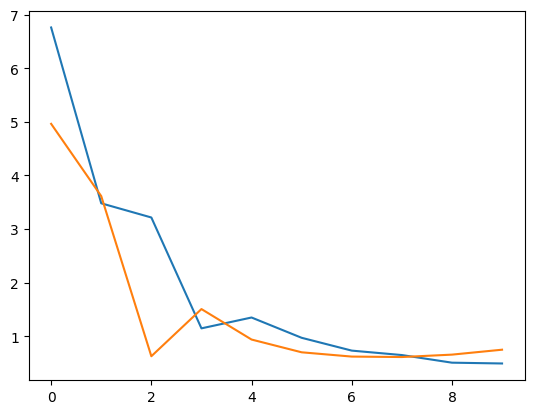

In [175]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [135]:
model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9000 - loss: 0.1317


[0.13170084357261658, 0.8999999761581421]